In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import warnings
import traceback

if '../' not in sys.path:
    sys.path.append('../')

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as lines
from scipy.interpolate import interp1d
from scipy.optimize import root_scalar

plt.style.use('../input/physrev.mplstyle')
plt.rcParams['figure.dpi'] = "300"

In [4]:
def load_csv(file_name, skip_header=0):
    plot_data = np.genfromtxt(file_name, delimiter=',', skip_header=skip_header)
    
    x = list(zip(*plot_data))[0]
    y = list(zip(*plot_data))[1]
    
    return x, y

### ACT Stuff

In [5]:
act_central_value = 2.89
Dneff_act_68_errorbar = 0.11

### directory with N_eff results

In [6]:
highmass = False

In [7]:
# adm_results_dir = '/Users/duncan/scratch/adm_scans/adm_scan_fine/'
adm_results_dir = '/Users/duncan/scratch/adm_scans/adm_scan_jan15/'
if highmass:
    adm_results_dir = '/Users/duncan/scratch/adm_scans/adm_scan_highmass_notop/'

### Loop over directories to find all parameter points and load results

In [8]:
# N_eff_min_cut = 2.7

In [9]:
mde_dirs = []
mde_mdp_dirs = []

for name in os.listdir(adm_results_dir):
    if os.path.isdir(os.path.join(adm_results_dir, name)):
        mde_dirs.append(os.path.join(adm_results_dir, name))


for md in mde_dirs:
    for name in os.listdir(md):
        if os.path.isdir(os.path.join(md, name)):
            mde_mdp_dirs.append(os.path.join(md, name))
    
    

In [10]:
N_Q = 50
num_param_points = len(mde_mdp_dirs*N_Q)

m_de = np.zeros(num_param_points)
m_dp = np.zeros(num_param_points)
charges = np.zeros(num_param_points)
N_eff = np.zeros(num_param_points)
Delta_N_eff = np.zeros(num_param_points)
Delta_N_eff_dso = np.zeros(num_param_points)

R_Tnu_Tgam = np.zeros(num_param_points)
R_Tdark_Tgam = np.zeros(num_param_points)
R_Tgam_bsm_Tgam_sm = np.zeros(num_param_points)

res_ind = 0

for (i, res_dir) in enumerate(mde_mdp_dirs):
    result_files = [f for f in os.listdir(res_dir) if f.endswith('.npz')]
    
    for (j, rf) in enumerate(result_files):
        result = np.load(os.path.join(res_dir, rf))
        result_txt_fname = rf.split('.npz')[0] + '.txt'

        #very hacky way to get temperature ratios from text files
        result_txt = np.genfromtxt(
            os.path.join(res_dir, rf.split('.npz')[0] + '.txt'), 
            delimiter='=', 
            skip_footer=1,
            usecols=1
        )

        ratio_Tnu_Tg = result_txt[8]
        ratio_Td_Tg = result_txt[9]
        ratio_Tgbsm_Tgsm = result_txt[10]

        R_Tnu_Tgam[res_ind] = ratio_Tnu_Tg
        R_Tdark_Tgam[res_ind] = ratio_Td_Tg
        R_Tgam_bsm_Tgam_sm[res_ind] = ratio_Tgbsm_Tgsm 
        

        m_de[res_ind] = result['m_de']
        m_dp[res_ind] = result['m_dp']
        charges[res_ind] = result['Q']
        N_eff[res_ind] = result['N_eff_bsm']
        Delta_N_eff[res_ind] = result['Delta_Neff']
        Delta_N_eff_dso[res_ind] = result['DNeff_dso']


        res_ind += 1

failed_jobs = len(np.where(m_de == 0)[0])

In [11]:
failed_jobs

0

In [12]:
sel = np.where(m_de > 0)

m_de = m_de[sel]
m_dp = m_dp[sel]
charges = charges[sel]
N_eff = N_eff[sel]
Delta_N_eff = Delta_N_eff[sel]
Delta_N_eff_dso = Delta_N_eff_dso[sel]

R_Tnu_Tgam = R_Tnu_Tgam[sel]
R_Tdark_Tgam = R_Tdark_Tgam[sel]
R_Tgam_bsm_Tgam_sm = R_Tgam_bsm_Tgam_sm[sel]

In [13]:
R_Tdark_Tgam

array([0.08337496, 0.72571498, 0.72863356, ..., 1.00460139, 1.01864764,
       0.30211861])

In [14]:
R_Tnu_Tgam 

array([0.71428863, 0.68351249, 0.68427463, ..., 0.67964663, 0.68444629,
       0.71559808])

In [15]:
if highmass:
    resname = 'neff_scan_result_highmass.npz'
else:
    resname = 'neff_scan_result.npz'

np.savez_compressed(
    os.path.join('../output/results/',resname),
    m_de = m_de,
    m_dp = m_dp,
    eps = charges,
    N_eff = N_eff,
    R_Tnu_Tgam = R_Tnu_Tgam,
    R_Tdark_Tgam = R_Tdark_Tgam,
    R_Tgam_bsm_Tgam_sm = R_Tgam_bsm_Tgam_sm
    
)

### Plots

In [16]:
unique_mde = np.unique(m_de)

N_eff_min_cut = 0.1

N_eff_results_dict = dict()
Delta_N_eff_interp_dict = dict()
Delta_N_eff_dso_interp_dict = dict()
R_Tgam_Tdark_interp_dict = dict()

for um_de in unique_mde:
    m_dp_um = m_dp[np.where(m_de == um_de)]

    unique_mdp = np.unique(m_dp_um)

    results_dict = dict()
    interp_dict = dict()
    interp_dict_dso = dict()
    interp_dict_R = dict()

    for um_dp in unique_mdp:
        sel = np.where(
            (m_de == um_de)
           &(m_dp == um_dp)
        )

        charges_um_dp = charges[sel]
        N_eff_um_dp = N_eff[sel]
        Delta_N_eff_um_dp = Delta_N_eff[sel]
        Delta_N_eff_dso_um_dp = Delta_N_eff_dso[sel]
        R_Tdark_Tgam_um_dp = R_Tdark_Tgam[sel]

        sort_order = charges_um_dp.argsort()

        result_um_dp = np.array([
            charges_um_dp[sort_order], 
            N_eff_um_dp[sort_order],
            Delta_N_eff_um_dp[sort_order],
            Delta_N_eff_dso_um_dp[sort_order]
        ])

        #interpreter shouldn't have param points that failed
        Isel = np.where(N_eff_um_dp[sort_order] > N_eff_min_cut)

        if np.any(N_eff_um_dp[sort_order] == 0.0):
            print('wtf')

        dne_I = interp1d(
            charges_um_dp[sort_order][Isel], 
            Delta_N_eff_um_dp[sort_order][Isel], 
            bounds_error=False, 
            kind='cubic',
            fill_value=(Delta_N_eff_um_dp[sort_order][Isel][0], Delta_N_eff_um_dp[sort_order][Isel][-1])
        )

        dne_dso_I = interp1d(
            charges_um_dp[sort_order][Isel], 
            Delta_N_eff_dso_um_dp[sort_order][Isel], 
            bounds_error=False, 
            fill_value=(Delta_N_eff_dso_um_dp[sort_order][Isel][0], Delta_N_eff_dso_um_dp[sort_order][Isel][-1])
        )

        R_Tg_Td_I = interp1d(
            charges_um_dp[sort_order][Isel], 
            R_Tdark_Tgam_um_dp[sort_order][Isel], 
            bounds_error=False, 
            fill_value=(R_Tdark_Tgam[sort_order][Isel][0], R_Tdark_Tgam[sort_order][Isel][-1])
        )

        results_dict = results_dict | {um_dp: result_um_dp}
        interp_dict = interp_dict | {um_dp: dne_I}
        interp_dict_dso = interp_dict_dso | {um_dp: dne_dso_I}
        interp_dict_R = interp_dict_R | {um_dp: R_Tg_Td_I}

    N_eff_results_dict = N_eff_results_dict | {um_de: results_dict}
    Delta_N_eff_interp_dict = Delta_N_eff_interp_dict | {um_de: interp_dict}
    Delta_N_eff_dso_interp_dict = Delta_N_eff_dso_interp_dict | {um_de: interp_dict_dso}
    R_Tgam_Tdark_interp_dict = R_Tgam_Tdark_interp_dict | {um_de: interp_dict_R}

In [17]:
print(unique_mde)

[  0.1      0.1151   0.1326   0.1526   0.1758   0.2024   0.233    0.2683
   0.3089   0.3556   0.4095   0.4715   0.5429   0.6251   0.7197   0.8286
   0.9541   1.099    1.265    1.456    1.677    1.931    2.223    2.56
   2.947    3.393    3.907    4.498    5.179    5.964    6.866    7.906
   9.103   10.48    12.07    13.89    16.      18.42    21.21    24.42
  28.12    32.37    37.28    42.92    49.42    56.9     65.51    75.43
  86.85   100.    ]


In [18]:
eps_min = 1e-10
eps_max = 1e-4

num_eps = 50
charge_list = np.geomspace(eps_min, eps_max, num_eps)

## Make Neff contour plot in hydrogen and positronium limits

In [19]:
masses_HL = np.zeros((len(unique_mde), N_Q))
charges_HL = np.zeros((len(unique_mde), N_Q))
N_eff_HL = np.zeros((len(unique_mde), N_Q))
R_Td_Tg_HL = np.zeros((len(unique_mde), N_Q))

for (i, mass_de) in enumerate(unique_mde):

    HL_mdp_key = list(N_eff_results_dict[mass_de].keys())[-1]
    charges = N_eff_results_dict[mass_de][HL_mdp_key][0]
    N_eff = N_eff_results_dict[mass_de][HL_mdp_key][1]
    R_Td_Tg = R_Tgam_Tdark_interp_dict[mass_de][HL_mdp_key](charges)

    bad_points = np.where(N_eff < N_eff_min_cut)
    if len(bad_points[0]) > 0:
        for bp in bad_points:
            N_eff[bp] = Delta_N_eff_interp_dict[mass_de][HL_mdp_key](charge_list[bp]) + 3.008794963455335

    #in case of failed jobs
    num_completed = len(N_eff)

    masses_HL[i, :] = mass_de
    charges_HL[i, :] = charge_list 
    N_eff_HL[i, 0:num_completed] = N_eff
    R_Td_Tg_HL[i:, 0:num_completed] = R_Td_Tg

masses_PL = np.zeros((len(unique_mde), N_Q))
charges_PL = np.zeros((len(unique_mde), N_Q))
N_eff_PL = np.zeros((len(unique_mde), N_Q))
R_Td_Tg_PL = np.zeros((len(unique_mde), N_Q))

for (i, mass_de) in enumerate(unique_mde):

    PL_mdp_key = list(N_eff_results_dict[mass_de].keys())[0]
    N_eff = N_eff_results_dict[mass_de][PL_mdp_key][1]
    R_Td_Tg = R_Tgam_Tdark_interp_dict[mass_de][PL_mdp_key](charges)

    bad_points = np.where(N_eff < N_eff_min_cut)
    if len(bad_points[0]) > 0:
        for bp in bad_points:
            print(bp)
            N_eff[bp] = Delta_N_eff_interp_dict[mass_de][PL_mdp_key](charge_list[bp]) + 3.008794963455335
    # N_eff_I = Delta_N_eff_interp_dict[mass_de][PL_mdp_key]

    #in case of failed jobs
    num_completed = len(N_eff)

    masses_PL[i, :] = mass_de
    charges_PL[i, :] = charge_list 
    N_eff_PL[i, 0:num_completed] = N_eff
    R_Td_Tg_PL[i:, 0:num_completed] = R_Td_Tg

In [20]:
bad_points

(array([], dtype=int64),)

In [21]:
resname_HL = 'neff_scan_result_HL.npz'
resname_PL = 'neff_scan_result_PL.npz'
np.savez_compressed(
    os.path.join('../output/results/',resname_HL),
    m_de = masses_HL,
    m_dp = 1000*masses_HL,
    charge = charges_HL,
    N_eff = N_eff_HL,
    R_Tdark_Tgam = R_Td_Tg_PL
)

np.savez_compressed(
    os.path.join('../output/results/',resname_PL),
    m_de = masses_PL,
    m_dp = masses_PL,
    charge = charges_PL,
    N_eff = N_eff_PL,
    R_Tdark_Tgam = R_Td_Tg_PL
    
)

In [22]:
Delta_N_eff_interp_dict[mass_de][PL_mdp_key]

In [23]:
bad_sel = np.where(N_eff_PL < 1.0)

## This wont be used in the paper, instead we want to do an interpolation of results to make the plots smoother

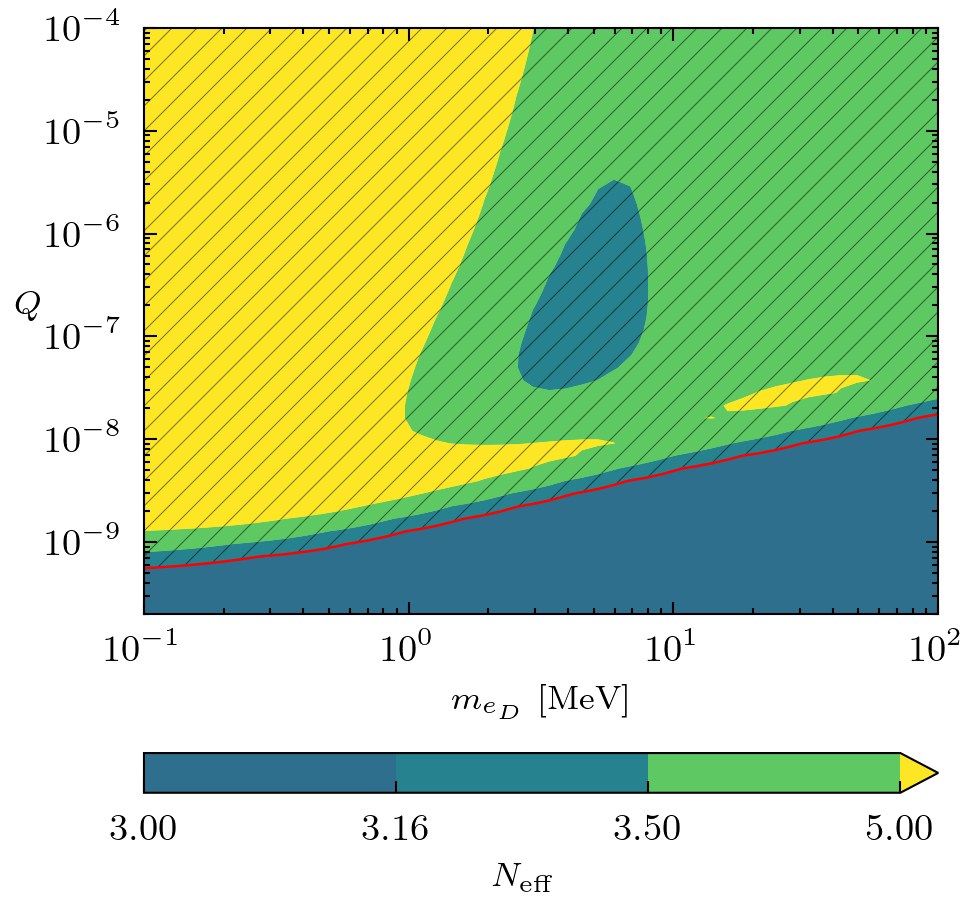

In [24]:
plt.rcParams['hatch.color'] = (0.0, 0.0, 0.0, 0.5)
hatch_style = '////'

#figsize=(3.25, 2.0)

f, ax = plt.subplots(
    1, 1, figsize=(3.25, 3.0), layout="constrained"
)
# contour_levels = np.array([3.0, 3.0 + 0.16, 3.5, 4, 5, 7, 10, 15])
# contour_levels = np.array([3.0, 3.0 + 0.16, 3.5, 5])
contour_levels = np.array([2.0, 3.0 - 0.16, 3.0, 3.0 + 0.16, 3.5, 5])

cont_alg = 'serial'

plt.contourf(
    masses_HL, 
    charges_HL,
    N_eff_HL, 
    levels=contour_levels,
    antialiased=True,
    extend='max',
    # cmap='cividis',
    algorithm = cont_alg,
    # colors=['C0', 'C1', 'C2', 'C3', 'C4', 'C5']
    # norm='log',
)

cbar = plt.colorbar(label=r'$N_{\rm eff}$', location='bottom')

plt.contourf(
    masses_HL, 
    charges_HL,
    N_eff_HL, 
    levels=contour_levels,
    antialiased=True,
    extend='max',
    hatches=[None, hatch_style, None, hatch_style, hatch_style, hatch_style],
    algorithm = cont_alg,
    # colors=['C0', 'C1', 'C2', 'C3', 'C4', 'C5'],
    # norm='log',
    # cmap='cividis',
)

plt.contour(
    masses_HL, 
    charges_HL,
    N_eff_HL, 
    # levels=np.array([3.0 - 0.16, 3.0 + 0.16]),
    levels=np.array([3.0 -0.16, 3.0 + 0.16]),
    colors='red',
    antialiased=True,
    # norm='log',
)

bad_sel = np.where(N_eff_PL < 2.4)
plt.plot(masses_PL[bad_sel], charges_PL[bad_sel], linestyle='none', marker='x')


plt.xlabel('$m_{e_D}~$[MeV]')
plt.ylabel(r'$Q$',  rotation='horizontal')

plt.ylim(2e-10, 1e-4)

plt.xscale('log')
plt.yscale('log')
cbar.ax.set_xlim(3.0, 5.0)

plt.savefig('../output/figures/N_eff_contour_HL.pdf')



plt.show()

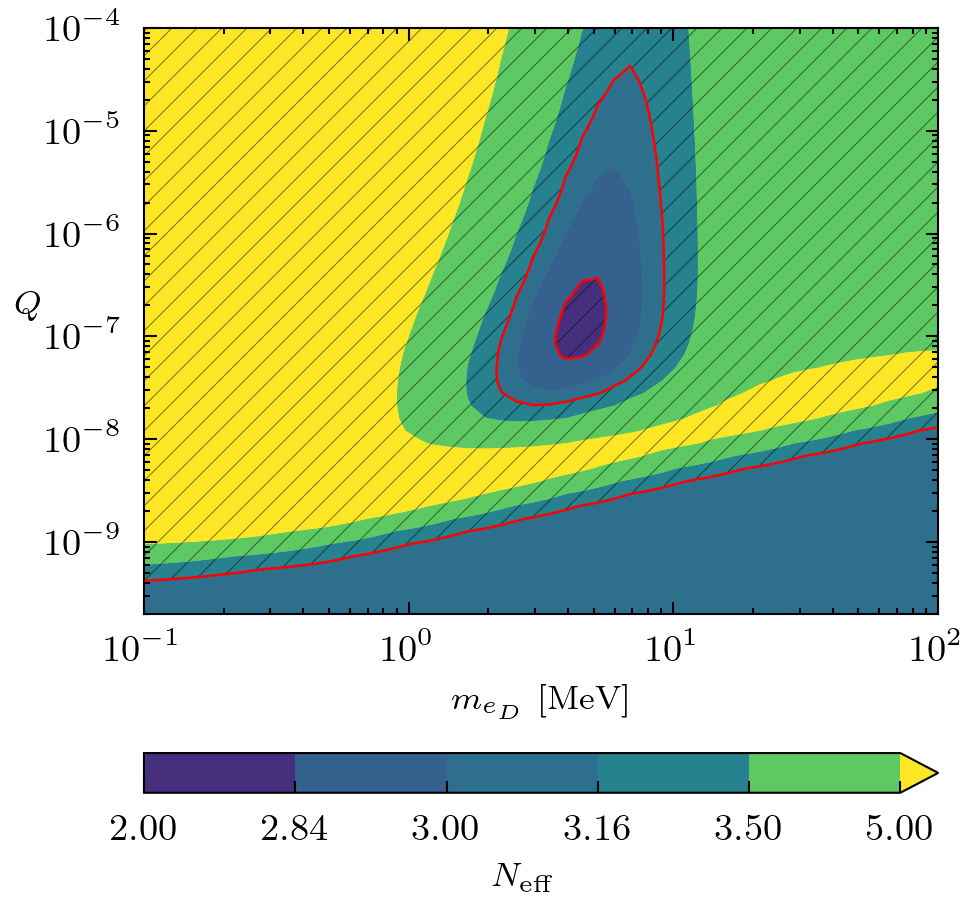

In [25]:
plt.rcParams['hatch.color'] = (0.0, 0.0, 0.0, 0.5)

f, ax = plt.subplots(
    1, 1, figsize=(3.25, 3.0), layout="constrained"
)
# contour_levels = np.array([3.0, 3.0 + 0.16, 3.5, 4, 5, 7, 10, 15])
contour_levels = np.array([2.0, 3.0 - 0.16, 3.0, 3.0 + 0.16, 3.5, 5])

plt.contourf(
    masses_PL, 
    charges_PL,
    N_eff_PL, 
    levels=contour_levels,
    antialiased=True,
    extend='max',
    # hatches=['x', 'x', None, 'x', 'x', 'x'],
    # norm='log',
    # cmap='cividis',
)

plt.colorbar(label=r'$N_{\rm eff}$', location='bottom')

hatch_style = 'xxx'
hatch_style = '////'

plt.contourf(
    masses_PL, 
    charges_PL,
    N_eff_PL, 
    levels=contour_levels,
    antialiased=True,
    extend='max',
    hatches=[hatch_style, None, None, hatch_style, hatch_style, hatch_style],
    # norm='log',
    # cmap='cividis',
)

plt.contour(
    masses_PL, 
    charges_PL,
    N_eff_PL, 
    # levels=np.array([3.0 - 0.16, 3.0 + 0.16]),
    levels=np.array([3.0 -0.16, 3.0 + 0.16]),
    colors='red',
    antialiased=True,
    # norm='log',
)

# plt.contourf(
#     masses_PL, 
#     charges_PL,
#     N_eff_PL, 
#     # levels=np.array([3.0 - 0.16, 3.0 + 0.16]),
#     levels=np.array([2.0, 3.0 - 0.16]),
#     colors=None,
#     hatches='x',
#     antialiased=True,
#     # norm='log',
# )

bad_sel = np.where(N_eff_PL < 2.4)
plt.plot(masses_PL[bad_sel], charges_PL[bad_sel], linestyle='none', marker='x')


plt.xlabel('$m_{e_D}~$[MeV]')
plt.ylabel(r'$Q$', rotation='horizontal')

plt.ylim(2e-10, 1e-4)

plt.xscale('log')
plt.yscale('log')

plt.savefig('../output/figures/N_eff_contour_PL.pdf')

plt.show()

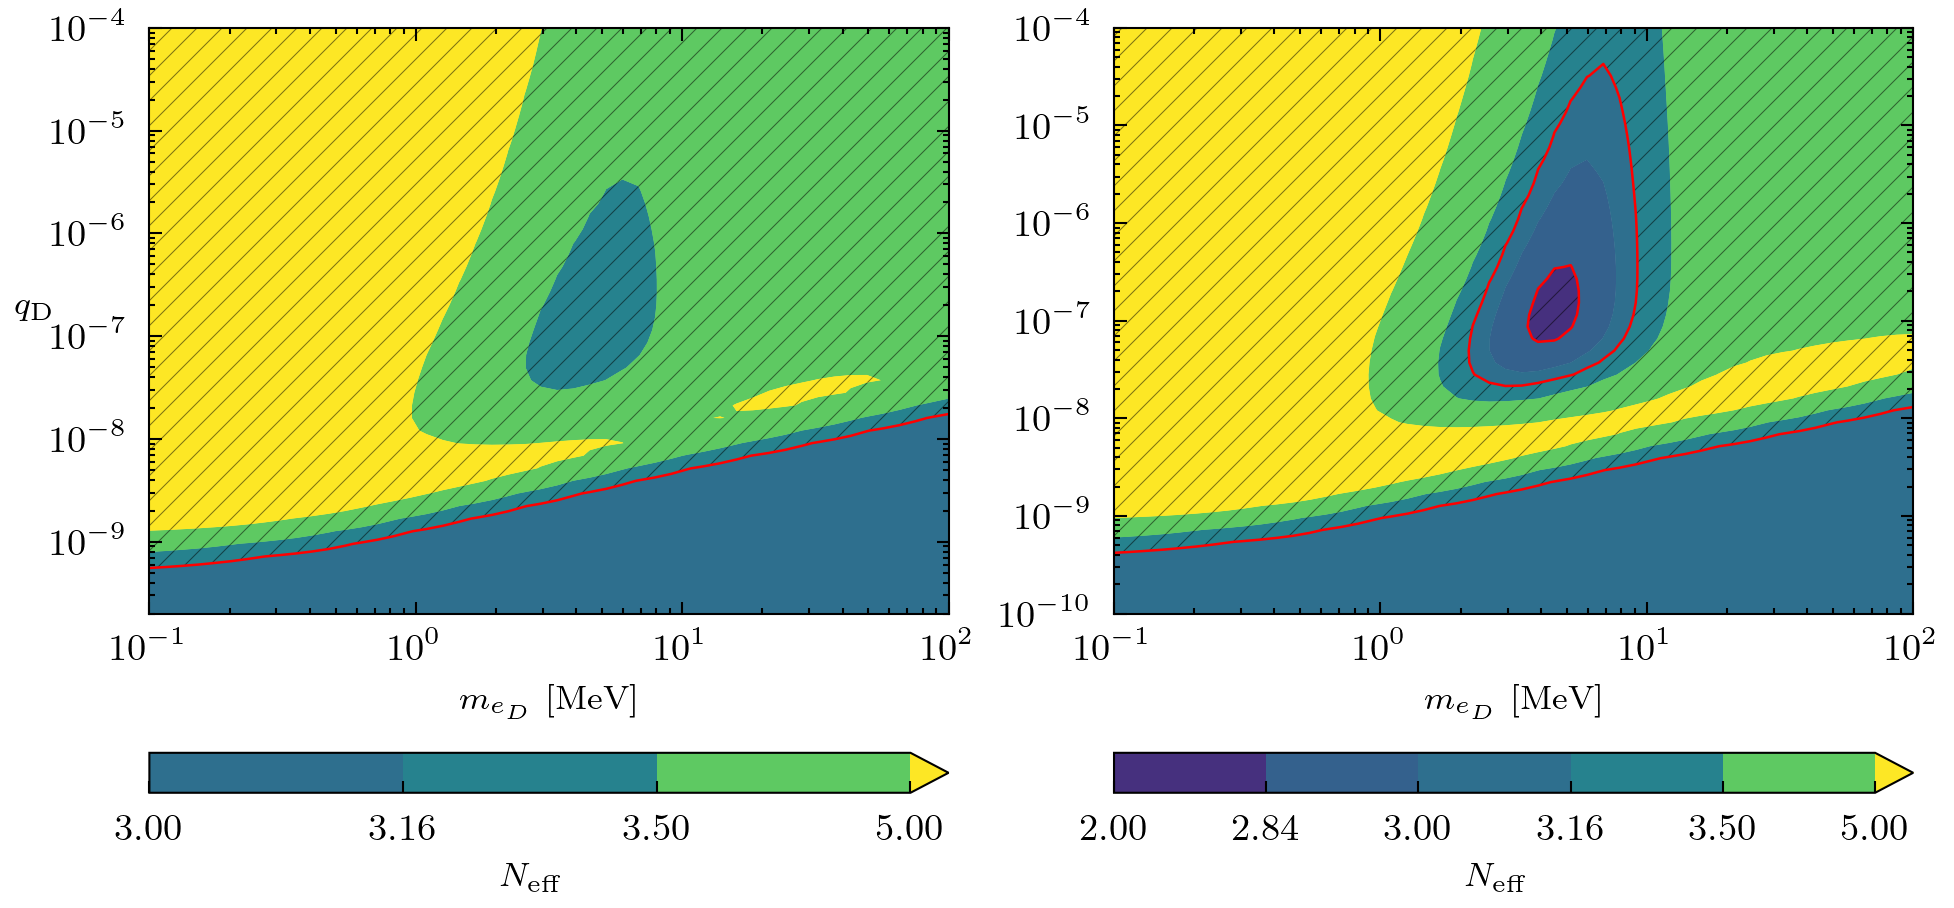

In [26]:
plt.rcParams['hatch.color'] = (0.0, 0.0, 0.0, 0.5)
hatch_style = '////'

#figsize=(3.25, 2.0)

f, ax = plt.subplots(
    1, 2, figsize=(2*3.25, 3.0), layout="constrained", sharey=False
)

plt.contourf

cont_kwargs = {
    'algorithm' : 'mpl2014',
    'extend': 'max',
    'antialiased': True
}

Dneff_constraint = 0.16

################################################################################################################
#Hydrogen limit
################################################################################################################
contour_levels_HL = np.array([2.0, 3.0 - Dneff_constraint, 3.0, 3.0 + Dneff_constraint, 3.5, 5])
hatches_HL = [None, hatch_style, None, hatch_style, hatch_style, hatch_style]

cont_quads_HL = ax[0].contourf(
    masses_HL, 
    charges_HL,
    N_eff_HL, 
    levels=contour_levels_HL,
    **cont_kwargs
)

cbar_HL = plt.colorbar(cont_quads_HL, label=r'$N_{\rm eff}$', location='bottom', ax=ax[0])
cbar_HL.ax.set_xlim(3.0, 5.0)

ax[0].contourf(
    masses_HL, 
    charges_HL,
    N_eff_HL, 
    levels=contour_levels_HL,
    hatches=hatches_HL,
    **cont_kwargs
)

ax[0].contour(
    masses_HL, 
    charges_HL,
    N_eff_HL, 
    levels=np.array([3.0 - Dneff_constraint, 3.0 + Dneff_constraint]),
    colors='red',
    antialiased=True,
)
################################################################################################################
# Positronium limit
################################################################################################################
contour_levels_PL =  np.array([2.0, 3.0 - Dneff_constraint, 3.0, 3.0 + Dneff_constraint, 3.5, 5])
hatches_PL = [hatch_style, None, None, hatch_style, hatch_style, hatch_style]

cont_quads_PL = ax[1].contourf(
    masses_PL, 
    charges_PL,
    N_eff_PL, 
    levels=contour_levels_PL,
    **cont_kwargs
)

cbar_PL = plt.colorbar(cont_quads_HL, label=r'$N_{\rm eff}$', location='bottom', ax=ax[1])

ax[1].contourf(
    masses_PL, 
    charges_PL,
    N_eff_PL, 
    levels=contour_levels_PL,
    hatches=hatches_PL,
    **cont_kwargs
)

ax[1].contour(
    masses_PL, 
    charges_PL,
    N_eff_PL, 
    levels=np.array([3.0 - Dneff_constraint, 3.0 + Dneff_constraint]),
    colors='red',
    antialiased=True,
)
################################################################################################################
ax[0].set_ylim(2e-10, 1e-4)
ax[0].set_yscale('log')
ax[0].set_ylabel(r'$q_{\rm D}$',  rotation='horizontal')

ax[1].set_ylim(1e-10, 1e-4)
ax[1].set_yscale('log')

ax[0].set_xlabel('$m_{e_D}~$[MeV]')
ax[0].set_xscale('log')

ax[1].set_xlabel('$m_{e_D}~$[MeV]')
ax[1].set_xscale('log')


plt.savefig('../output/figures/N_eff_contour_combined.pdf')

plt.show()

### A few test plots demonstrating why the contours arent so smooth

Text(0, 0.5, '$q_{\\rm D}$')

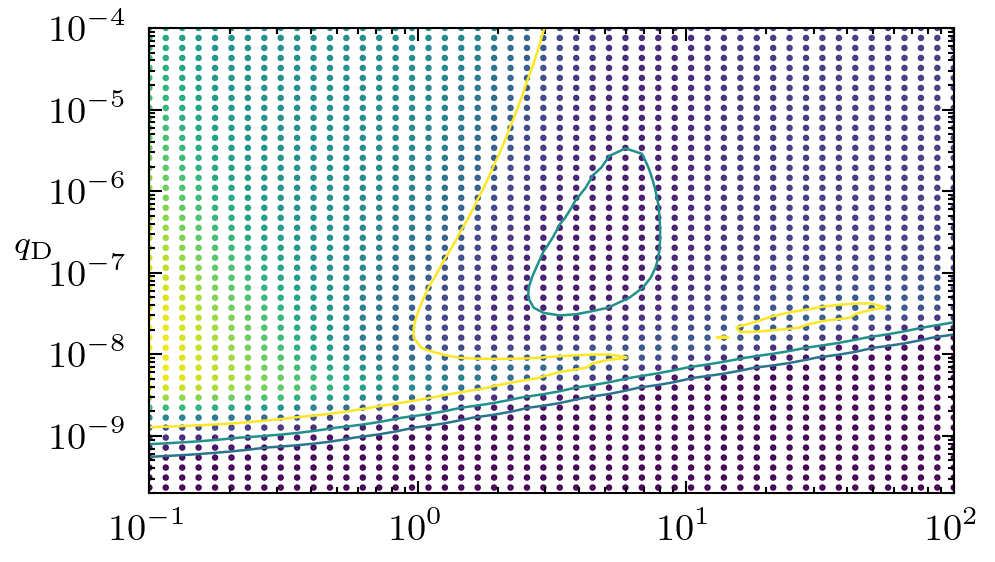

In [27]:
plt.contour(
    masses_HL, 
    charges_HL,
    N_eff_HL, 
    levels=contour_levels_HL,
    hatches=hatches_HL,
    **cont_kwargs
)

plt.scatter(
    masses_HL, 
    charges_HL,
    c=N_eff_HL, 
    s=0.3,
    norm='log'
)

plt.ylim(2e-10, 1e-4)
plt.yscale('log')
plt.xscale('log')
plt.ylabel(r'$q_{\rm D}$',  rotation='horizontal')

In [28]:
eps_range = np.geomspace(1e-10, 1e-4, 100)

results_fine = np.zeros((len(masses_HL), 100))
masses_fine = np.zeros((len(masses_HL), 100))
charges_fine = np.zeros((len(masses_HL), 100))

for (i, mass_de) in enumerate(unique_mde):
    HL_mdp_key = list(N_eff_results_dict[mass_de].keys())[-1]

    Q = charges_PL[0, :]
    N_eff = N_eff_results_dict[mass_de][HL_mdp_key][1]

    interpF = interp1d(Q, N_eff)

    results_fine[i, :] = interpF(eps_range)
    masses_fine[i, :] = mass_de
    charges_fine[i, :] = eps_range

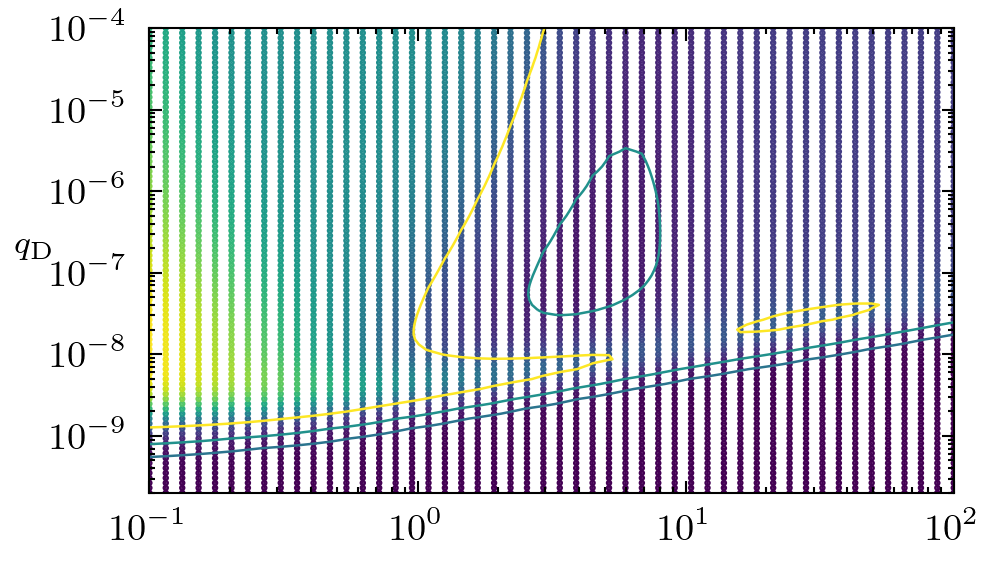

In [29]:
plt.scatter(masses_fine, charges_fine, c=results_fine, s = 0.3, norm='log')
plt.ylim(2e-10, 1e-4)
plt.yscale('log')
plt.xscale('log')
plt.ylabel(r'$q_{\rm D}$',  rotation='horizontal')

plt.contour(
    masses_fine, 
    charges_fine,
    results_fine, 
    levels=contour_levels_HL,
    hatches=hatches_HL,
    **cont_kwargs
)

### Run the results on a finer grid with 2d cubic interpolation

In [30]:
from scipy.interpolate import RegularGridInterpolator, LinearNDInterpolator

In [31]:
_masses_I = np.unique(masses_HL)
_charges_I = np.unique(charges_HL)
_method = 'cubic'

HL_Neff_interp = RegularGridInterpolator((_masses_I, _charges_I), N_eff_HL, method=_method)
PL_Neff_interp = RegularGridInterpolator((_masses_I, _charges_I), N_eff_PL, method=_method)

HL_R_interp = RegularGridInterpolator((_masses_I, _charges_I), R_Td_Tg_HL, method=_method)
PL_R_interp = RegularGridInterpolator((_masses_I, _charges_I), R_Td_Tg_PL, method=_method)



Text(0, 0.5, '$q_{\\rm D}$')

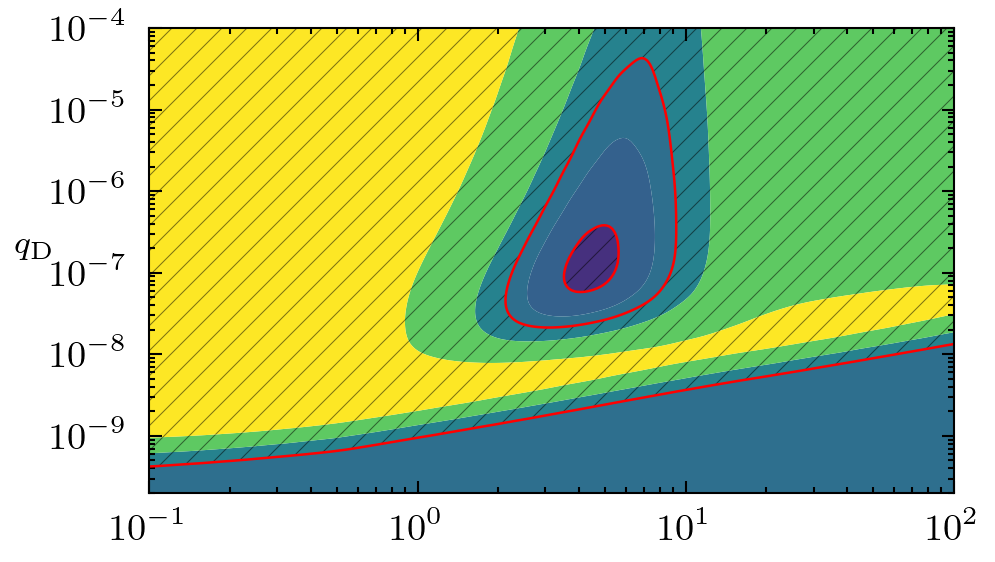

In [32]:
Mplot, Qplot = np.meshgrid(
    np.geomspace(0.1, 100, 300), 
    np.geomspace(1e-10, 1e-4, 300), 
    indexing='ij'
)


plt.contourf(
    Mplot, 
    Qplot,
    PL_Neff_interp((Mplot, Qplot)), 
    levels=contour_levels_PL,
    hatches=hatches_PL,
    **cont_kwargs
)

plt.contour(
    Mplot, 
    Qplot,
    PL_Neff_interp((Mplot, Qplot)), 
    levels=np.array([3.0 - Dneff_constraint, 3.0 + Dneff_constraint]),
    hatches=hatches_PL,
    colors='red',
    **cont_kwargs
)

plt.ylim(2e-10, 1e-4)
plt.yscale('log')
plt.xscale('log')
plt.ylabel(r'$q_{\rm D}$',  rotation='horizontal')


## Paper Quality Neff Contours assuming a central value of 3.01

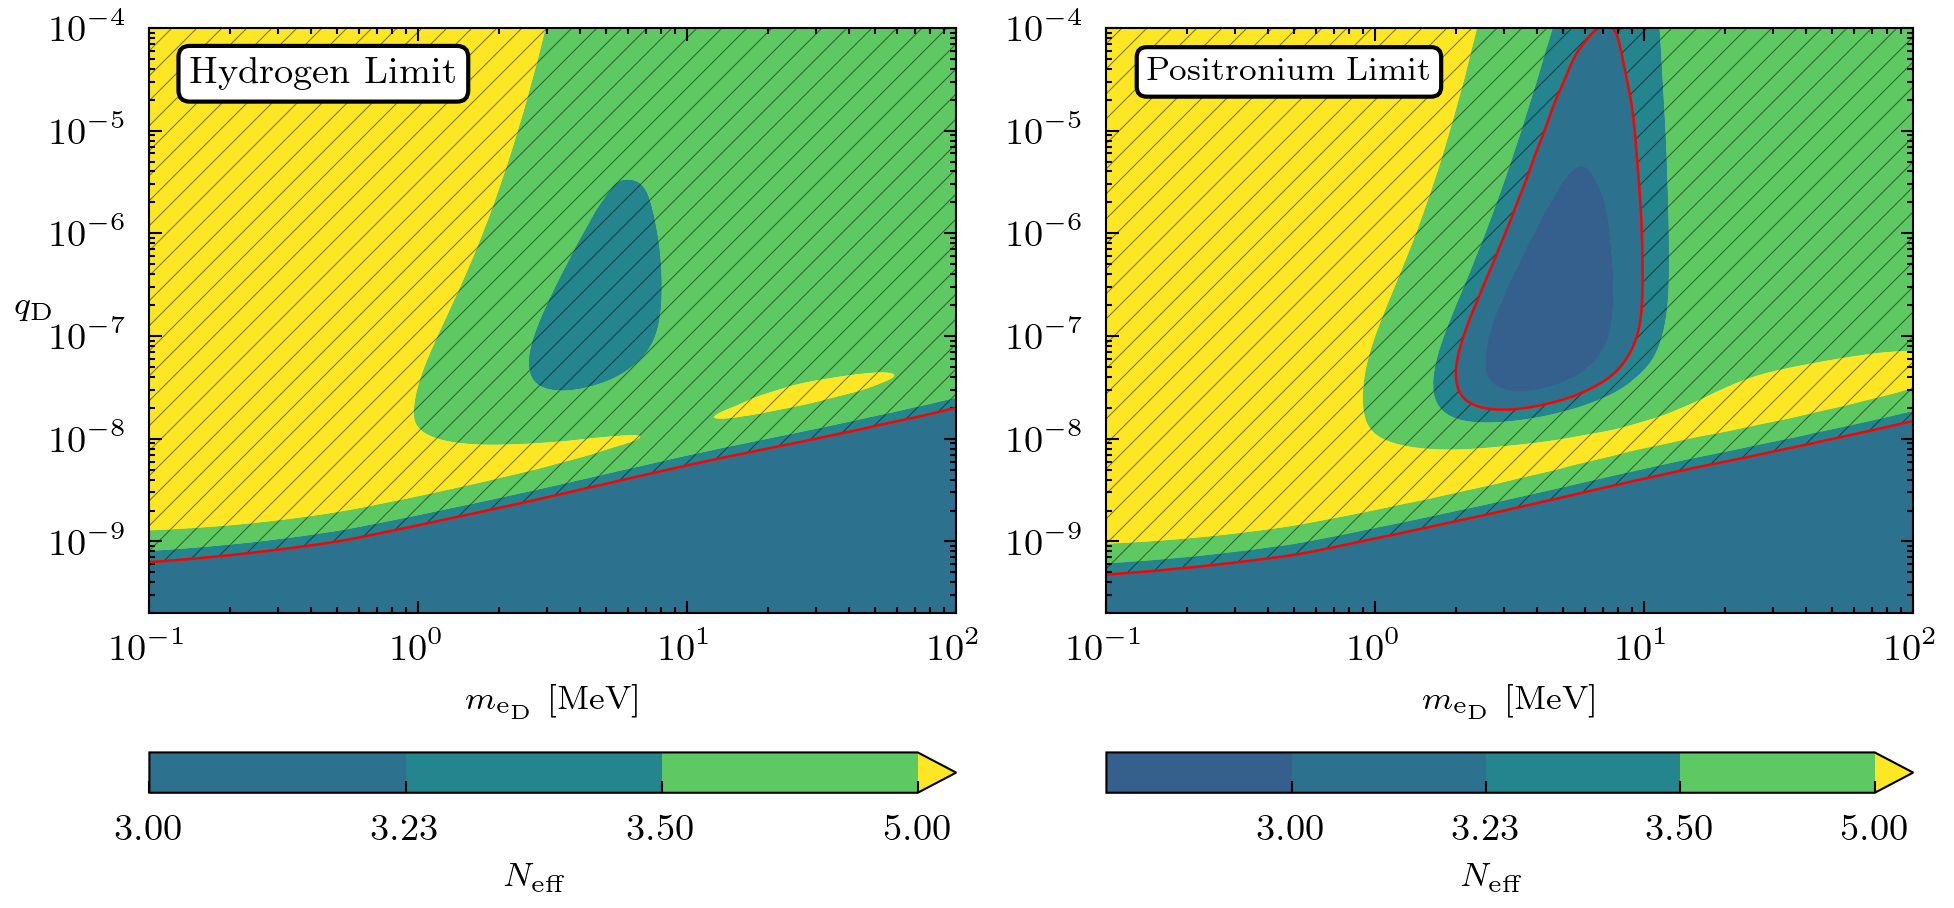

In [33]:
plt.rcParams['hatch.color'] = (0.0, 0.0, 0.0, 0.5)
hatch_style = '////'

#figsize=(3.25, 2.0)

f, ax = plt.subplots(
    1, 2, figsize=(2*3.25, 3.0), layout="constrained", sharey=False
)

plt.contourf

cont_kwargs = {
    'algorithm' : 'mpl2014',
    'extend': 'max',
    'antialiased': True
}




################################################################################################################
#Hydrogen limit
################################################################################################################

contour_levels_HL = np.array([2.0, 3.01 - 2*Dneff_act_68_errorbar, 3.0, 3.01 + 2*Dneff_act_68_errorbar, 3.5, 5])
# contour_levels_HL = np.array([2.0, act_central_value  - 2*Dneff_act_68_errorbar, 3.0, act_central_value + 2*Dneff_act_68_errorbar, 3.5, 5])

hatches_HL = [None, hatch_style, None, hatch_style, hatch_style, hatch_style]

contour_lines_HL =  np.array([3.01 - 2*Dneff_act_68_errorbar, 3.01 + 2*Dneff_act_68_errorbar]) #for ACT
# contour_lines_HL =  np.array([act_central_value - 2*Dneff_act_68_errorbar, act_central_value + 2*Dneff_act_68_errorbar]) #for ACT

cont_quads_HL = ax[0].contourf(
    Mplot, 
    Qplot,
    HL_Neff_interp((Mplot, Qplot)), 
    levels=contour_levels_HL,
    **cont_kwargs
)

cbar_HL = plt.colorbar(cont_quads_HL, label=r'$N_{\rm eff}$', location='bottom', ax=ax[0])
cbar_HL.ax.set_xlim(3.0, 5.0)

ax[0].contourf(
    Mplot, 
    Qplot,
    HL_Neff_interp((Mplot, Qplot)), 
    levels=contour_levels_HL,
    hatches=hatches_HL,
    **cont_kwargs
)

ax[0].contour(
    Mplot, 
    Qplot,
    HL_Neff_interp((Mplot, Qplot)), 
    levels=contour_lines_HL,
    colors='red',
    antialiased=True,
)

props = dict(boxstyle='round', facecolor='white', alpha=1.0)

ax[0].text(0.05, 0.95, r'Hydrogen Limit', transform=ax[0].transAxes, fontsize=9,
        verticalalignment='top', bbox=props)

hatch_leg_patch = mpatches.Patch(
    edgecolor='black', 
    facecolor=(0, 0, 0, 0.0), 
    linewidth=0.15, 
    hatch=r'////',
    label=r'$|\Delta N_{\rm eff}| > 0.22$'
)

# ax[0].legend(
#     handles=[hatch_leg_patch],
#     loc='upper left', 
#     bbox_to_anchor=(0.018, 0.883), 
#     edgecolor='black'
# )

################################################################################################################
# Positronium limit
################################################################################################################


contour_levels_PL =  np.array([2.0, 3.01 - 2*Dneff_act_68_errorbar, 3.0, 3.01 + 2*Dneff_act_68_errorbar, 3.5, 5])
# contour_levels_PL =  np.array([2.0, act_central_value - 2*Dneff_act_68_errorbar, 3.0, act_central_value + 2*Dneff_act_68_errorbar, 3.5, 5]) ## for ACT

hatches_PL = [hatch_style, None, None, hatch_style, hatch_style, hatch_style]

contour_lines_PL =  np.array([3.01 - 2*Dneff_act_68_errorbar, 3.01 + 2*Dneff_act_68_errorbar])
# contour_lines_PL =  np.array([act_central_value - 2*Dneff_act_68_errorbar, act_central_value + 2*Dneff_act_68_errorbar]) #for ACT

cont_quads_PL = ax[1].contourf(
    masses_PL, 
    charges_PL,
    N_eff_PL, 
    levels=contour_levels_PL,
    **cont_kwargs
)

cbar_PL = plt.colorbar(cont_quads_HL, label=r'$N_{\rm eff}$', location='bottom', ax=ax[1])
cbar_PL.ax.set_xlim(2.8, 5.0)

ax[1].contourf(
    Mplot, 
    Qplot,
    PL_Neff_interp((Mplot, Qplot)), 
    levels=contour_levels_PL,
    hatches=hatches_PL,
    **cont_kwargs
)

ax[1].contour(
    Mplot, 
    Qplot,
    PL_Neff_interp((Mplot, Qplot)), 
    levels=contour_lines_PL,
    colors='red',
    antialiased=True,
)


################################################################################################################
ax[0].set_ylim(2e-10, 1e-4)
ax[0].set_yscale('log')
ax[0].set_ylabel(r'$q_{\rm D}$',  rotation='horizontal')

ax[1].set_ylim(2e-10, 1e-4)
ax[1].set_yscale('log')

ax[0].set_xlabel(r'$m_{\rm{e_D}}~$[MeV]')
ax[0].set_xscale('log')

ax[1].set_xlabel(r'$m_{\rm{e_D}}~$[MeV]')
ax[1].set_xscale('log')

sn1987a_fid = load_csv('../input/fig/SN1987A_mcp_fiducial.csv')
sn1987a_nakazato = load_csv('../input/fig/SN1987A_mcp_nakazato.csv')

# plt.plot(Mplot, Qplot, color='red', label='ruled out'))

props = dict(boxstyle='round', facecolor='white', alpha=1.0)
ax[1].text(0.05, 0.95, r'Positronium Limit', transform=ax[1].transAxes, fontsize=8,
        verticalalignment='top', bbox=props)

hatch_leg_patch = mpatches.Patch(
    edgecolor='black', 
    facecolor=(0, 0, 0, 0.0), 
    linewidth=0.15, 
    hatch=r'////',
    label=r'$|\Delta N_{\rm eff}| > 0.22$'
)

# dummy_line = ax[1].plot([], [], label='Positronium Limit', linestyle=None, color='None')

# ax[1].legend(
#     handles=[dummy_line[0], hatch_leg_patch],
#     loc='upper left', 
#     # bbox_to_anchor=(0.02, 0.88), 
#     edgecolor='black'
# )

dummy_line = ax[1].plot([], [], label='Positronium Limit', linestyle=None, color='None')

# ax[1].legend(
#     handles=[hatch_leg_patch],
#     loc='upper left', 
#     bbox_to_anchor=(0.018, 0.89), 
#     edgecolor='black'
# )

ax[0].plot(1, 1, color='red', label='Ruled Out')
# ax[0].legend(loc='upper left', bbox_to_anchor=(0.02, 0.88))

# ax[1].scatter(*sn1987a_fid, s=0.4, color='black')
# ax[1].scatter(*sn1987a_nakazato, s=0.4, color='purple')
# ax[1].scatter(sn1987a_nakazato[0], sn1987a_nakazato[1]/np.sqrt(2), s=0.4, color='purple')
ax[1].set_xlim(1e-1, 100)


plt.savefig('../output/figures/N_eff_contour_combined_baseline_act_errors.pdf')
# plt.savefig('../output/figures/N_eff_contour_combined_act_central_act_errors.pdf')

plt.show()

## Paper quality contours for Act central value 2.86

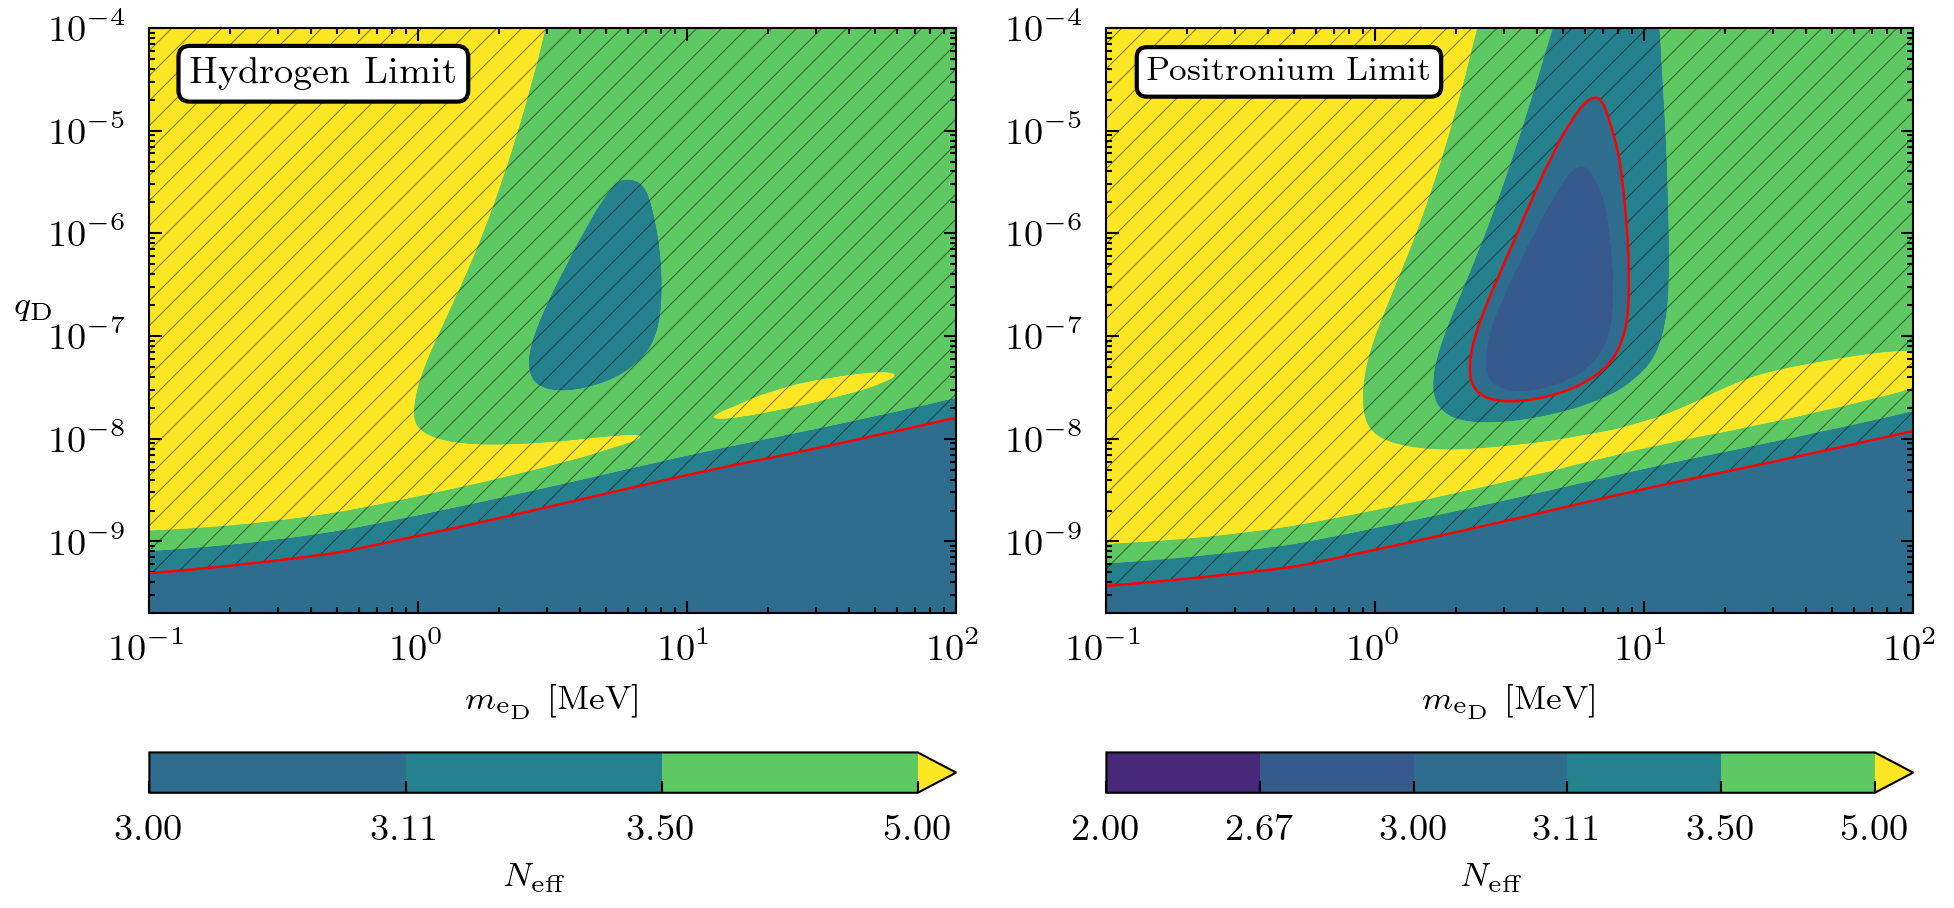

In [34]:
plt.rcParams['hatch.color'] = (0.0, 0.0, 0.0, 0.5)
hatch_style = '////'

#figsize=(3.25, 2.0)

f, ax = plt.subplots(
    1, 2, figsize=(2*COL_WIDTH, FIG_HEIGHT), layout="constrained", sharey=False
)

plt.contourf

cont_kwargs = {
    'algorithm' : 'mpl2014',
    'extend': 'max',
    'antialiased': True
}


################################################################################################################
#Hydrogen limit
################################################################################################################

# contour_levels_HL = np.array([2.0, 3.01 - 2*Dneff_act_68_errorbar, 3.0, 3.01 + 2*Dneff_act_68_errorbar, 3.5, 5])
contour_levels_HL = np.array([2.0, act_central_value  - 2*Dneff_act_68_errorbar, 3.0, act_central_value + 2*Dneff_act_68_errorbar, 3.5, 5])

hatches_HL = [None, hatch_style, None, hatch_style, hatch_style, hatch_style]

# contour_lines_HL =  np.array([3.01 - 2*Dneff_act_68_errorbar, 3.01 + 2*Dneff_act_68_errorbar]) #for ACT
contour_lines_HL =  np.array([act_central_value - 2*Dneff_act_68_errorbar, act_central_value + 2*Dneff_act_68_errorbar]) #for ACT

cont_quads_HL = ax[0].contourf(
    Mplot, 
    Qplot,
    HL_Neff_interp((Mplot, Qplot)), 
    levels=contour_levels_HL,
    **cont_kwargs
)

cbar_HL = plt.colorbar(cont_quads_HL, label=r'$N_{\rm eff}$', location='bottom', ax=ax[0])
cbar_HL.ax.set_xlim(3.0, 5.0)

ax[0].contourf(
    Mplot, 
    Qplot,
    HL_Neff_interp((Mplot, Qplot)), 
    levels=contour_levels_HL,
    hatches=hatches_HL,
    **cont_kwargs
)

ax[0].contour(
    Mplot, 
    Qplot,
    HL_Neff_interp((Mplot, Qplot)), 
    levels=contour_lines_HL,
    colors='red',
    antialiased=True,
)

props = dict(boxstyle='round', facecolor='white', alpha=1.0)

ax[0].text(0.05, 0.95, r'Hydrogen Limit', transform=ax[0].transAxes, fontsize=9,
        verticalalignment='top', bbox=props)

hatch_leg_patch = mpatches.Patch(
    edgecolor='black', 
    facecolor=(0, 0, 0, 0.0), 
    linewidth=0.15, 
    hatch=r'////',
    label=r'$|\Delta N_{\rm eff}| > 0.22$'
)

# ax[0].legend(
#     handles=[hatch_leg_patch],
#     loc='upper left', 
#     bbox_to_anchor=(0.018, 0.883), 
#     edgecolor='black'
# )

################################################################################################################
# Positronium limit
################################################################################################################


# contour_levels_PL =  np.array([2.0, 3.01 - 2*Dneff_act_68_errorbar, 3.0, 3.01 + 2*Dneff_act_68_errorbar, 3.5, 5])
contour_levels_PL =  np.array([2.0, act_central_value - 2*Dneff_act_68_errorbar, 3.0, act_central_value + 2*Dneff_act_68_errorbar, 3.5, 5]) ## for ACT

hatches_PL = [hatch_style, None, None, hatch_style, hatch_style, hatch_style]

# contour_lines_PL =  np.array([3.01 - 2*Dneff_act_68_errorbar, 3.01 + 2*Dneff_act_68_errorbar])
contour_lines_PL =  np.array([act_central_value - 2*Dneff_act_68_errorbar, act_central_value + 2*Dneff_act_68_errorbar]) #for ACT

cont_quads_PL = ax[1].contourf(
    masses_PL, 
    charges_PL,
    N_eff_PL, 
    levels=contour_levels_PL,
    **cont_kwargs
)

cbar_PL = plt.colorbar(cont_quads_HL, label=r'$N_{\rm eff}$', location='bottom', ax=ax[1])
cbar_PL.ax.set_xlim(2.0, 5.0)

ax[1].contourf(
    Mplot, 
    Qplot,
    PL_Neff_interp((Mplot, Qplot)), 
    levels=contour_levels_PL,
    hatches=hatches_PL,
    **cont_kwargs
)

ax[1].contour(
    Mplot, 
    Qplot,
    PL_Neff_interp((Mplot, Qplot)), 
    levels=contour_lines_PL,
    colors='red',
    antialiased=True,
)


################################################################################################################
ax[0].set_ylim(2e-10, 1e-4)
ax[0].set_yscale('log')
ax[0].set_ylabel(r'$q_{\rm D}$',  rotation='horizontal')

ax[1].set_ylim(2e-10, 1e-4)
ax[1].set_yscale('log')

ax[0].set_xlabel(r'$m_{\rm{e_D}}~$[MeV]')
ax[0].set_xscale('log')

ax[1].set_xlabel(r'$m_{\rm{e_D}}~$[MeV]')
ax[1].set_xscale('log')

sn1987a_fid = load_csv('../input/fig/SN1987A_mcp_fiducial.csv')
sn1987a_nakazato = load_csv('../input/fig/SN1987A_mcp_nakazato.csv')

# plt.plot(Mplot, Qplot, color='red', label='ruled out'))

props = dict(boxstyle='round', facecolor='white', alpha=1.0)
ax[1].text(0.05, 0.95, r'Positronium Limit', transform=ax[1].transAxes, fontsize=8,
        verticalalignment='top', bbox=props)

hatch_leg_patch = mpatches.Patch(
    edgecolor='black', 
    facecolor=(0, 0, 0, 0.0), 
    linewidth=0.15, 
    hatch=r'////',
    label=r'$|\Delta N_{\rm eff}| > 0.22$'
)

# dummy_line = ax[1].plot([], [], label='Positronium Limit', linestyle=None, color='None')

# ax[1].legend(
#     handles=[dummy_line[0], hatch_leg_patch],
#     loc='upper left', 
#     # bbox_to_anchor=(0.02, 0.88), 
#     edgecolor='black'
# )

dummy_line = ax[1].plot([], [], label='Positronium Limit', linestyle=None, color='None')

# ax[1].legend(
#     handles=[hatch_leg_patch],
#     loc='upper left', 
#     bbox_to_anchor=(0.018, 0.89), 
#     edgecolor='black'
# )

ax[0].plot(1, 1, color='red', label='Ruled Out')
# ax[0].legend(loc='upper left', bbox_to_anchor=(0.02, 0.88))

# ax[1].scatter(*sn1987a_fid, s=0.4, color='black')
# ax[1].scatter(*sn1987a_nakazato, s=0.4, color='purple')
# ax[1].scatter(sn1987a_nakazato[0], sn1987a_nakazato[1]/np.sqrt(2), s=0.4, color='purple')
ax[1].set_xlim(1e-1, 100)


# plt.savefig('../output/figures/N_eff_contour_combined_baseline_act_errors.pdf')
plt.savefig('../output/figures/N_eff_contour_combined_act_central_act_errors.pdf')

plt.show()

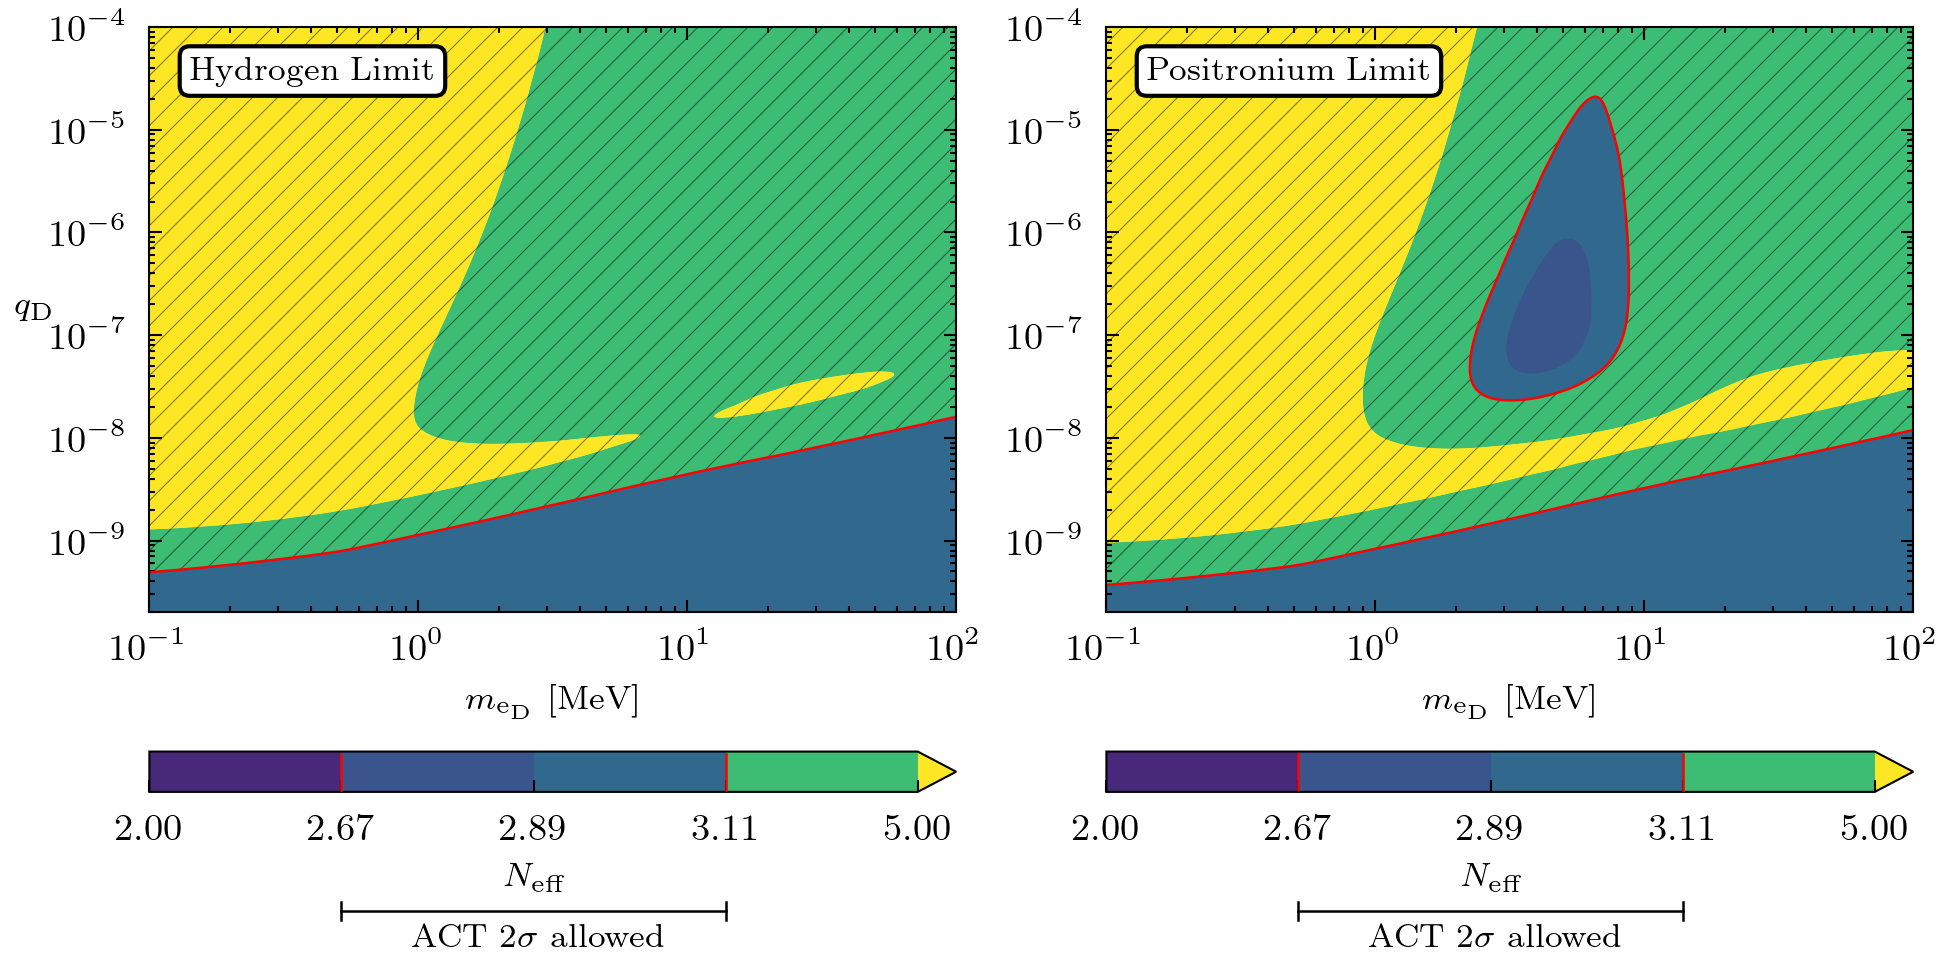

In [35]:
plt.rcParams['hatch.color'] = (0.0, 0.0, 0.0, 0.5)
hatch_style = '////'

#figsize=(3.25, 2.0)

f, ax = plt.subplots(
    1, 2, figsize=(2*3.25, 3.0), layout="constrained", sharey=False
)

plt.contourf

cont_kwargs = {
    'algorithm' : 'mpl2014',
    'extend': 'max',
    'antialiased': True
}



################################################################################################################
#Hydrogen limit
################################################################################################################

# contour_levels_HL = np.array([2.0, 3.01 - 2*Dneff_act_68_errorbar, 3.0, 3.01 + 2*Dneff_act_68_errorbar, 3.5, 5])
contour_levels_HL = np.array([2.0, act_central_value  - 2*Dneff_act_68_errorbar, act_central_value, act_central_value + 2*Dneff_act_68_errorbar, 5])

hatches_HL = [None, hatch_style, None, hatch_style,  hatch_style]

# contour_lines_HL =  np.array([3.01 - 2*Dneff_act_68_errorbar, 3.01 + 2*Dneff_act_68_errorbar]) #for ACT
contour_lines_HL =  np.array([act_central_value - 2*Dneff_act_68_errorbar, act_central_value + 2*Dneff_act_68_errorbar]) #for ACT

cont_quads_HL = ax[0].contourf(
    Mplot, 
    Qplot,
    HL_Neff_interp((Mplot, Qplot)), 
    levels=contour_levels_HL,
    **cont_kwargs
)

cbar_HL = plt.colorbar(cont_quads_HL, label=r'$N_{\rm eff}$', location='bottom', ax=ax[0])
cbar_HL.ax.set_xlim(2.0, 5.0)

ax[0].contourf(
    Mplot, 
    Qplot,
    HL_Neff_interp((Mplot, Qplot)), 
    levels=contour_levels_HL,
    hatches=hatches_HL,
    **cont_kwargs
)

ax[0].contour(
    Mplot, 
    Qplot,
    HL_Neff_interp((Mplot, Qplot)), 
    levels=contour_lines_HL,
    colors='red',
    antialiased=True,
)

props = dict(boxstyle='round', facecolor='white', alpha=1.0)

ax[0].text(0.05, 0.95, r'Hydrogen Limit', transform=ax[0].transAxes, fontsize=8,
        verticalalignment='top', bbox=props)

hatch_leg_patch = mpatches.Patch(
    edgecolor='black', 
    facecolor=(0, 0, 0, 0.0), 
    linewidth=0.15, 
    hatch=r'////',
    label=r'$|\Delta N_{\rm eff}| > 0.22$'
)

################################################################################################################
# Positronium limit
################################################################################################################


# contour_levels_PL =  np.array([2.0, 3.01 - 2*Dneff_act_68_errorbar, 3.0, 3.01 + 2*Dneff_act_68_errorbar, 3.5, 5])
contour_levels_PL =  np.array([2.0, act_central_value - 2*Dneff_act_68_errorbar, act_central_value, act_central_value + 2*Dneff_act_68_errorbar, 5]) ## for ACT

hatches_PL = [hatch_style, None, None, hatch_style, hatch_style]

# contour_lines_PL =  np.array([3.01 - 2*Dneff_act_68_errorbar, 3.01 + 2*Dneff_act_68_errorbar])
contour_lines_PL =  np.array([act_central_value - 2*Dneff_act_68_errorbar, act_central_value + 2*Dneff_act_68_errorbar]) #for ACT

cont_quads_PL = ax[1].contourf(
    masses_PL, 
    charges_PL,
    N_eff_PL, 
    levels=contour_levels_PL,
    **cont_kwargs
)

cbar_PL = plt.colorbar(cont_quads_HL, label=r'$N_{\rm eff}$', location='bottom', ax=ax[1])
cbar_PL.ax.set_xlim(2.0, 5.0)

ax[1].contourf(
    Mplot, 
    Qplot,
    PL_Neff_interp((Mplot, Qplot)), 
    levels=contour_levels_PL,
    hatches=hatches_PL,
    **cont_kwargs
)

ax[1].contour(
    Mplot, 
    Qplot,
    PL_Neff_interp((Mplot, Qplot)), 
    levels=contour_lines_PL,
    colors='red',
    antialiased=True,
)


################################################################################################################
ax[0].set_ylim(2e-10, 1e-4)
ax[0].set_yscale('log')
ax[0].set_ylabel(r'$q_{\rm D}$',  rotation='horizontal')

ax[1].set_ylim(2e-10, 1e-4)
ax[1].set_yscale('log')

ax[0].set_xlabel(r'$m_{\rm{e_D}}~$[MeV]')
ax[0].set_xscale('log')

ax[1].set_xlabel(r'$m_{\rm{e_D}}~$[MeV]')
ax[1].set_xscale('log')

sn1987a_fid = load_csv('../input/fig/SN1987A_mcp_fiducial.csv')
sn1987a_nakazato = load_csv('../input/fig/SN1987A_mcp_nakazato.csv')

# plt.plot(Mplot, Qplot, color='red', label='ruled out'))

props = dict(boxstyle='round', facecolor='white', alpha=1.0)
ax[1].text(0.05, 0.95, r'Positronium Limit', transform=ax[1].transAxes, fontsize=8,
        verticalalignment='top', bbox=props)

ax[0].plot(1, 1, color='red', label='Ruled Out')
# ax[0].legend(loc='upper left', bbox_to_anchor=(0.02, 0.88))

# ax[1].scatter(sn1987a_fid[0][80:], sn1987a_fid[1][80:], s=0.4, color='black')
# ax[1].scatter(sn1987a_fid[0][0:80], sn1987a_fid[1][0:80]/np.sqrt(2), s=0.4, color='black')
# ax[1].scatter(*sn1987a_nakazato, s=0.4, color='purple')
# ax[1].scatter(sn1987a_nakazato[0], sn1987a_nakazato[1]/np.sqrt(2), s=0.4, color='purple')
ax[1].set_xlim(1e-1, 100)


f.add_artist(lines.Line2D([0.1738, 0.1738], [-0.02, 0.0], color='black'))
f.add_artist(lines.Line2D([0.3708, 0.3708], [-0.02, 0.0], color='black'))
f.add_artist(lines.Line2D([0.1738, 0.3708], [-0.01, -0.01], color='black'))

f.add_artist(lines.Line2D([0.1738, 0.1738], [0.1238, 0.1638], color='red'))
f.add_artist(lines.Line2D([0.3708, 0.3708], [0.1238, 0.1638], color='red'))

f.text(0.21, -0.05, r'ACT $2\sigma$ allowed', fontsize=8)

dx1 = .4908
dx2 = .4909

f.add_artist(lines.Line2D([0.1738 + dx1, 0.1738 + dx1], [-0.02, 0.0], color='black'))
f.add_artist(lines.Line2D([0.3708 + dx2, 0.3708 + dx2], [-0.02, 0.0], color='black'))
f.add_artist(lines.Line2D([0.1738 + dx1, 0.3708 + dx2], [-0.01, -0.01], color='black'))

f.add_artist(lines.Line2D([0.1738 + dx1, 0.1738 + dx2], [0.1238, 0.1638], color='red'))
f.add_artist(lines.Line2D([0.3708 + dx2, 0.3708 + dx2], [0.1238, 0.1638], color='red'))

f.text(0.21 + dx1, -0.05, r'ACT $2\sigma$ allowed', fontsize=8)


# plt.savefig('../output/figures/N_eff_contour_combined_baseline_act_errors.pdf')
plt.savefig('../output/figures/N_eff_contour_combined_act_central_act_errors.pdf')

plt.show()

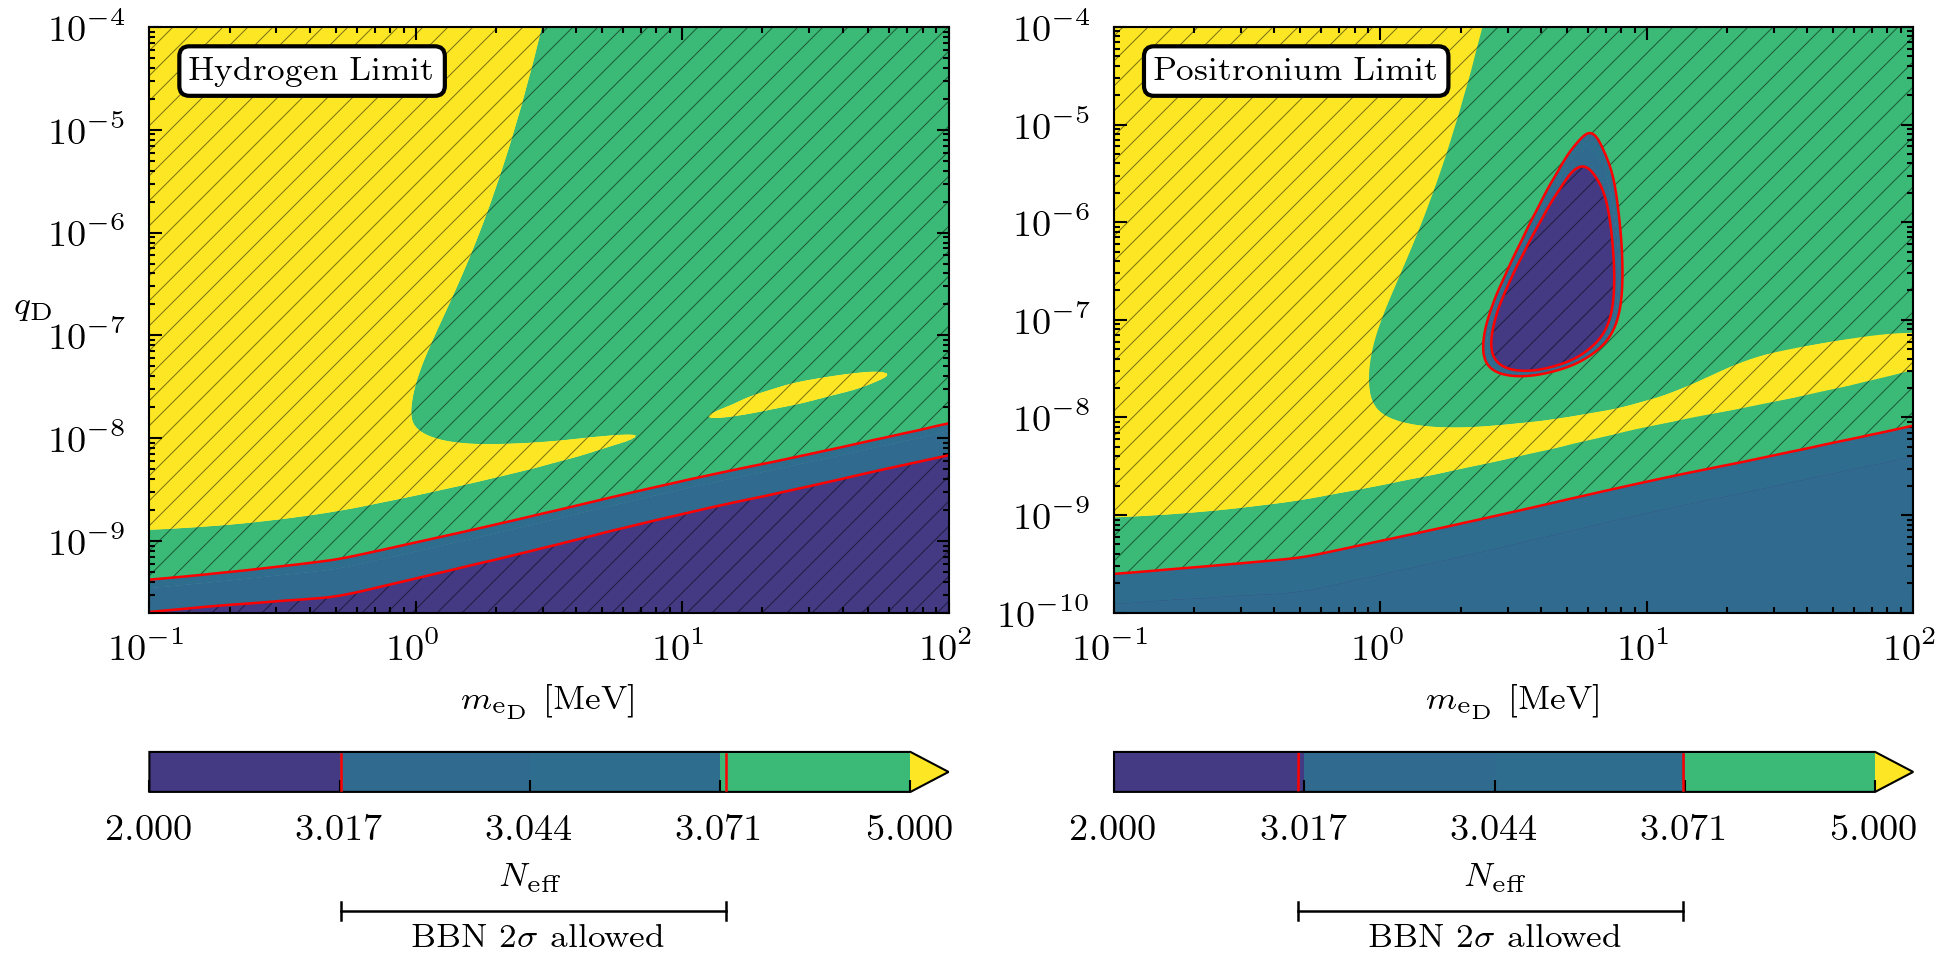

In [36]:
central_value_he4 = 3.044

errorbar_1sig_he4 = 0.027/2

plt.rcParams['hatch.color'] = (0.0, 0.0, 0.0, 0.5)
hatch_style = '////'

#figsize=(3.25, 2.0)

f, ax = plt.subplots(
    1, 2, figsize=(2*3.25, 3.0), layout="constrained", sharey=False
)

plt.contourf

cont_kwargs = {
    'algorithm' : 'mpl2014',
    'extend': 'max',
    'antialiased': True
}



################################################################################################################
#Hydrogen limit
################################################################################################################

# contour_levels_HL = np.array([2.0, 3.04 - 2*Dneff_act_68_errorbar, 3.04, 3.04 + 2*Dneff_act_68_errorbar, 5])
contour_levels_HL = np.array([2.0, central_value_he4 - 2*errorbar_1sig_he4, central_value_he4, central_value_he4+ 2*errorbar_1sig_he4 , 5])

# contour_levels_HL = np.array([2.0, act_central_value  - 2*Dneff_act_68_errorbar, act_central_value, act_central_value + 2*Dneff_act_68_errorbar, 5])

hatches_HL = [hatch_style, None, None, hatch_style,  hatch_style]

contour_lines_HL =  np.array([central_value_he4 - 2*errorbar_1sig_he4, central_value_he4 + 2*errorbar_1sig_he4]) #for ACT
# contour_lines_HL =  np.array([act_central_value - 2*Dneff_act_68_errorbar, act_central_value + 2*Dneff_act_68_errorbar]) #for ACT

cont_quads_HL = ax[0].contourf(
    Mplot, 
    Qplot,
    HL_Neff_interp((Mplot, Qplot)), 
    levels=contour_levels_HL,
    **cont_kwargs
)

cbar_HL = plt.colorbar(cont_quads_HL, label=r'$N_{\rm eff}$', location='bottom', ax=ax[0])
cbar_HL.ax.set_xlim(2.0, 5.0)

ax[0].contourf(
    Mplot, 
    Qplot,
    HL_Neff_interp((Mplot, Qplot)), 
    levels=contour_levels_HL,
    hatches=hatches_HL,
    **cont_kwargs
)

ax[0].contour(
    Mplot, 
    Qplot,
    HL_Neff_interp((Mplot, Qplot)), 
    levels=contour_lines_HL,
    colors='red',
    antialiased=True,
)

props = dict(boxstyle='round', facecolor='white', alpha=1.0)

ax[0].text(0.05, 0.95, r'Hydrogen Limit', transform=ax[0].transAxes, fontsize=8,
        verticalalignment='top', bbox=props)

hatch_leg_patch = mpatches.Patch(
    edgecolor='black', 
    facecolor=(0, 0, 0, 0.0), 
    linewidth=0.15, 
    hatch=r'////',
    label=r'$|\Delta N_{\rm eff}| > 0.22$'
)

################################################################################################################
# Positronium limit
################################################################################################################


contour_levels_PL =  np.array([2.0, central_value_he4 - 2*errorbar_1sig_he4, central_value_he4, central_value_he4 + 2*errorbar_1sig_he4, 5])
# contour_levels_PL =  np.array([2.0, act_central_value - 2*Dneff_act_68_errorbar, act_central_value, act_central_value + 2*Dneff_act_68_errorbar, 5]) ## for ACT

hatches_PL = [hatch_style, None, None, hatch_style, hatch_style]

contour_lines_PL =  np.array([central_value_he4 - 2*errorbar_1sig_he4, central_value_he4 + 2*errorbar_1sig_he4])
# contour_lines_PL =  np.array([act_central_value - 2*Dneff_act_68_errorbar, act_central_value + 2*Dneff_act_68_errorbar]) #for ACT

cont_quads_PL = ax[1].contourf(
    masses_PL, 
    charges_PL,
    N_eff_PL, 
    levels=contour_levels_PL,
    **cont_kwargs
)

cbar_PL = plt.colorbar(cont_quads_HL, label=r'$N_{\rm eff}$', location='bottom', ax=ax[1])
cbar_PL.ax.set_xlim(2.0, 5.0)

ax[1].contourf(
    Mplot, 
    Qplot,
    PL_Neff_interp((Mplot, Qplot)) + 0.03, 
    levels=contour_levels_PL,
    hatches=hatches_PL,
    **cont_kwargs
)

ax[1].contour(
    Mplot, 
    Qplot,
    PL_Neff_interp((Mplot, Qplot))+ 0.03, 
    levels=contour_lines_PL,
    colors='red',
    antialiased=True,
)


################################################################################################################
ax[0].set_ylim(2e-10, 1e-4)
ax[0].set_yscale('log')
ax[0].set_ylabel(r'$q_{\rm D}$',  rotation='horizontal')

ax[1].set_ylim(1e-10, 1e-4)
ax[1].set_yscale('log')

ax[0].set_xlabel(r'$m_{\rm{e_D}}~$[MeV]')
ax[0].set_xscale('log')

ax[1].set_xlabel(r'$m_{\rm{e_D}}~$[MeV]')
ax[1].set_xscale('log')

sn1987a_fid = load_csv('../input/fig/SN1987A_mcp_fiducial.csv')
sn1987a_nakazato = load_csv('../input/fig/SN1987A_mcp_nakazato.csv')

# plt.plot(Mplot, Qplot, color='red', label='ruled out'))

props = dict(boxstyle='round', facecolor='white', alpha=1.0)
ax[1].text(0.05, 0.95, r'Positronium Limit', transform=ax[1].transAxes, fontsize=8,
        verticalalignment='top', bbox=props)

ax[0].plot(1, 1, color='red', label='Ruled Out')
# ax[0].legend(loc='upper left', bbox_to_anchor=(0.02, 0.88))

# ax[1].scatter(sn1987a_fid[0][80:], sn1987a_fid[1][80:], s=0.4, color='black')
# ax[1].scatter(sn1987a_fid[0][0:80], sn1987a_fid[1][0:80]/np.sqrt(2), s=0.4, color='black')
# ax[1].scatter(*sn1987a_nakazato, s=0.4, color='purple')
# ax[1].scatter(sn1987a_nakazato[0], sn1987a_nakazato[1]/np.sqrt(2), s=0.4, color='purple')
ax[1].set_xlim(1e-1, 100)


f.add_artist(lines.Line2D([0.1738, 0.1738], [-0.02, 0.0], color='black'))
f.add_artist(lines.Line2D([0.3708, 0.3708], [-0.02, 0.0], color='black'))
f.add_artist(lines.Line2D([0.1738, 0.3708], [-0.01, -0.01], color='black'))

f.add_artist(lines.Line2D([0.1738, 0.1738], [0.1238, 0.1638], color='red'))
f.add_artist(lines.Line2D([0.3708, 0.3708], [0.1238, 0.1638], color='red'))

f.text(0.21, -0.05, r'BBN $2\sigma$ allowed', fontsize=8)

dx1 = .4908
dx2 = .4909

f.add_artist(lines.Line2D([0.1738 + dx1, 0.1738 + dx1], [-0.02, 0.0], color='black'))
f.add_artist(lines.Line2D([0.3708 + dx2, 0.3708 + dx2], [-0.02, 0.0], color='black'))
f.add_artist(lines.Line2D([0.1738 + dx1, 0.3708 + dx2], [-0.01, -0.01], color='black'))

f.add_artist(lines.Line2D([0.1738 + dx1, 0.1738 + dx2], [0.1238, 0.1638], color='red'))
f.add_artist(lines.Line2D([0.3708 + dx2, 0.3708 + dx2], [0.1238, 0.1638], color='red'))

f.text(0.21 + dx1, -0.05, r'BBN $2\sigma$ allowed', fontsize=8)


plt.savefig('../output/figures/N_eff_contour_BBN.pdf')
# plt.savefig('../output/figures/N_eff_contour_combined_act_central_act_errors.pdf')

plt.show()

In [37]:
charges

array([1.000e-10, 1.326e-10, 1.758e-10, 2.330e-10, 3.089e-10, 4.095e-10,
       5.429e-10, 7.197e-10, 9.541e-10, 1.265e-09, 1.677e-09, 2.223e-09,
       2.947e-09, 3.907e-09, 5.179e-09, 6.866e-09, 9.103e-09, 1.207e-08,
       1.600e-08, 2.121e-08, 2.812e-08, 3.728e-08, 4.942e-08, 6.551e-08,
       8.685e-08, 1.151e-07, 1.526e-07, 2.024e-07, 2.683e-07, 3.556e-07,
       4.715e-07, 6.251e-07, 8.286e-07, 1.099e-06, 1.456e-06, 1.931e-06,
       2.560e-06, 3.393e-06, 4.498e-06, 5.964e-06, 7.906e-06, 1.048e-05,
       1.389e-05, 1.842e-05, 2.442e-05, 3.237e-05, 4.292e-05, 5.690e-05,
       7.543e-05, 1.000e-04])

In [38]:
PL_Neff_interp((100, 1e-10))

array(3.00880163)

## Save interpolated results

In [39]:
resname_HL_interpolated = 'neff_scan_result_HL_interp.npz'
resname_PL_interpolated  = 'neff_scan_result_PL_interp.npz'
np.savez_compressed(
    os.path.join('../output/results/',resname_HL_interpolated ),
    m_de = Mplot,
    m_dp = 1000*Mplot,
    charge = Qplot,
    N_eff = HL_Neff_interp((Mplot, Qplot)),
    R_Tdark_Tgam = HL_R_interp((Mplot, Qplot))
)

np.savez_compressed(
    os.path.join('../output/results/',resname_PL_interpolated),
    m_de = Mplot,
    m_dp = Mplot,
    charge = Qplot,
    N_eff = PL_Neff_interp((Mplot, Qplot)),
    R_Tdark_Tgam = PL_R_interp((Mplot, Qplot))
    
)

### Interpolated results at fixed mPD for plots

## paper quality plot showing 1d slice of Neff at fixed m_de with multiple curves for different m_dp

In [41]:
from scipy.interpolate import make_smoothing_spline

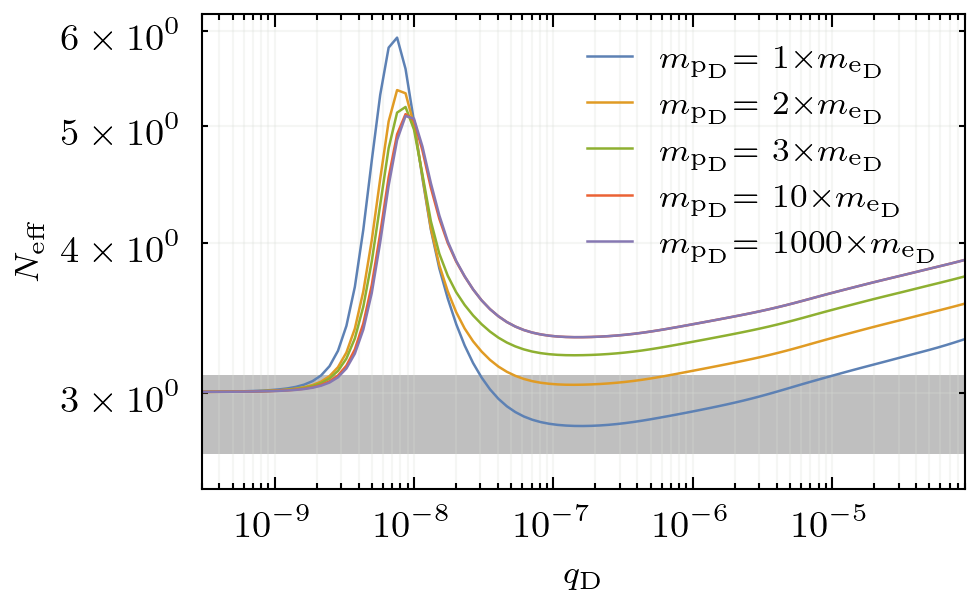

In [50]:
f, ax = plt.subplots(
    1, 1, figsize=(3.25, 2.0), layout="constrained"
)


m_de_plot = unique_mde[28] # ~5 MeV for paper
# m_de_plot = unique_mde[49]

results_keys = np.array(list(N_eff_results_dict[m_de_plot].keys()))
# keys_to_run = np.array([0, 1, 9, 12, 13], dtype=int)
keys_to_run = np.array([0, 1, 2, 9, 13], dtype=int) #for paper
# keys_to_run = np.array([0], dtype=int)

for m_dp in results_keys[keys_to_run]:
    charges_plot = N_eff_results_dict[m_de_plot][m_dp][0]
    N_eff_plot = N_eff_results_dict[m_de_plot][m_dp][1]

    res_I = interp1d(charges_plot, N_eff_plot, kind='cubic')
    charges_fine = np.geomspace(charges_plot[0], charges_plot[-1], 100)
    
    # plt.plot(charges_plot, N_eff_plot, label=f'{m_dp/m_de_plot:.2f}')
    plt.plot(charges_fine, res_I(charges_fine), label=r'$m_{\rm{p_D}}$= '+f'{m_dp/m_de_plot:.0f}' + r'$\times m_{\rm{e_D}}$')
    # plt.plot(charges_plot, N_eff_plot)

plt.xscale('log')
plt.xlabel(r'$q_{\rm D}$')
plt.ylabel(r'$N_{\rm eff}$')
plt.legend(loc=1, framealpha=0.0)
# plt.title(f'Dark Electron Mass: {m_de_plot:.2e} MeV')

plt.fill_between(charges_fine, 
                 act_central_value - 2*Dneff_act_68_errorbar, 
                 act_central_value + 2*Dneff_act_68_errorbar, 
                 color='gray', 
                 alpha=0.5,
                 edgecolor=None          
                )
plt.grid(which='both', axis='x', linestyle='solid', alpha=0.25)
plt.grid(which='both', axis='y', linestyle='solid', alpha=0.25)
plt.xlim(charges_fine[0], charges_fine[-1])
plt.ylim(2.5, 6.2)
plt.xlim(3e-10, 9e-5)

# plt.ylim(3.105, 3.115)
# plt.xlim(1e-8, 2e-8)

plt.yscale('log')
# plt.savefig('../output/figures/N_eff_1d_slice_m_de_5.18.pdf')
plt.show()

In [ ]:
res_I(charges_plot)

In [ ]:
np.array(list(N_eff_results_dict[m_de_plot].keys()))

In [ ]:
results_keys/m_de_plot

In [ ]:
print(m_de_plot)

In [ ]:
 unique_mde[28]